In [64]:
import pandas as pd

df = pd.read_csv("titanic_train.csv")

df.shape

(891, 12)

In [65]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [66]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [67]:
df = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Survived"]]

df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [51]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Survived    0
dtype: int64

In [52]:
from sklearn.preprocessing import LabelEncoder

encoder_sex = LabelEncoder()
encoder_embarked = LabelEncoder()

df["Sex"] = encoder_sex.fit_transform(df["Sex"])
df["Embarked"] = encoder_embarked.fit_transform(df["Embarked"])

df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,1,22.0,1,0,7.2500,2,0
1,1,0,38.0,1,0,71.2833,0,1
2,3,0,26.0,0,0,7.9250,2,1
3,1,0,35.0,1,0,53.1000,2,1
4,3,1,35.0,0,0,8.0500,2,0


In [53]:
df = df.sample(frac=1, random_state=42)

df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
709,3,1,28.0,1,1,15.2458,0,1
439,2,1,31.0,0,0,10.5000,2,0
840,3,1,20.0,0,0,7.9250,2,0
720,2,0,6.0,0,1,33.0000,2,1
39,3,0,14.0,1,0,11.2417,0,1
...,...,...,...,...,...,...,...,...
106,3,0,21.0,0,0,7.6500,2,1
270,1,1,28.0,0,0,31.0000,2,0
860,3,1,41.0,2,0,14.1083,2,0
435,1,0,14.0,1,2,120.0000,2,1


In [54]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, :-1]   # todas las columnas menos Survived
Y = df.iloc[:, -1]    # columna Survived

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,      # 20% prueba, 80% entrenamiento
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (712, 7)
Prueba: (179, 7)


In [55]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(
    criterion="gini",
    max_depth= None,
    random_state=42
)

In [56]:
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

resultados = cross_val_score(
    modelo,
    X_train,
    Y_train,
    cv=kfold,
    scoring="accuracy"
)

resultados

array([0.80898876, 0.78651685, 0.86516854, 0.84269663])

In [57]:
for i, resultado in enumerate(resultados, start=1):
    print(f"Fold {i}: {resultado:.4f}")

Fold 1: 0.8090
Fold 2: 0.7865
Fold 3: 0.8652
Fold 4: 0.8427


In [58]:
promedio = resultados.mean()

print("Promedio de accuracy:", promedio)

Promedio de accuracy: 0.8258426966292135


In [59]:
modelo.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

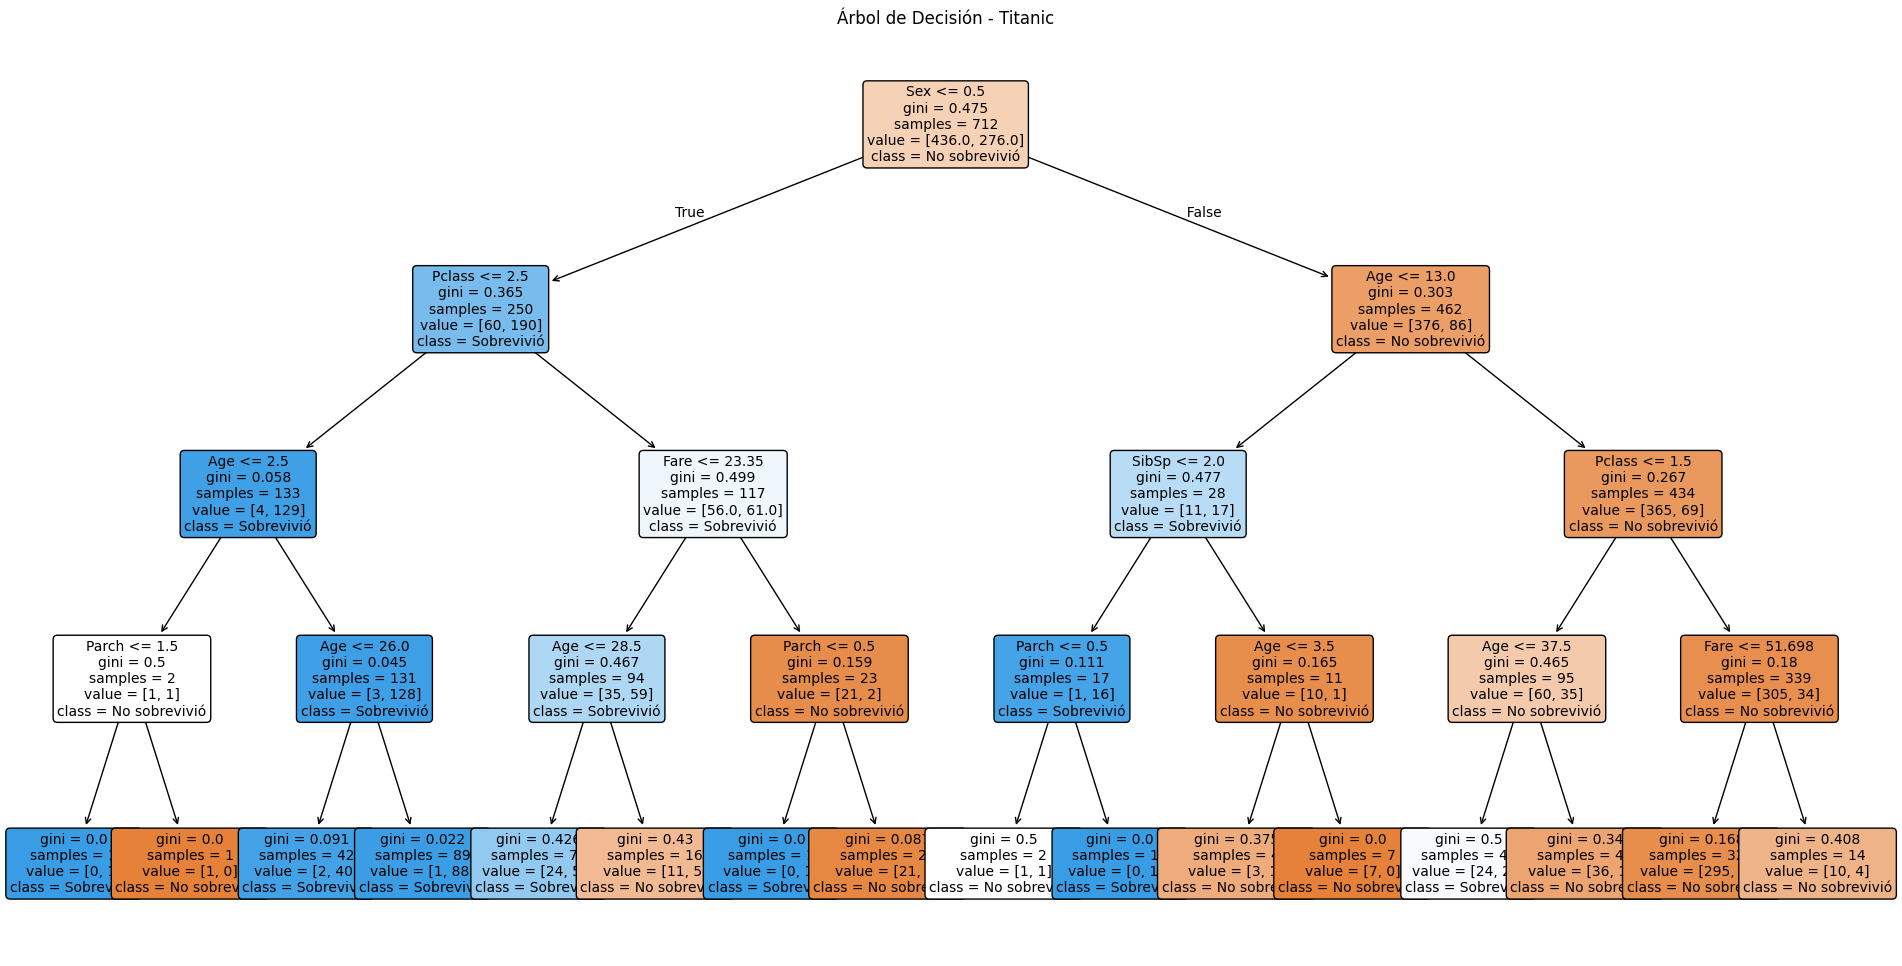

In [60]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))

plot_tree(
    modelo,
    feature_names=X_train.columns,
    class_names=["No sobrevivió", "Sobrevivió"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de Decisión - Titanic")
plt.show()

In [61]:
from sklearn.metrics import accuracy_score

Y_pred = modelo.predict(X_test)
print("Accuracy en prueba (20%):", accuracy_score(Y_test, Y_pred))

Accuracy en prueba (20%): 0.7206703910614525


In [62]:
X_test = pd.DataFrame({
    "Pclass": [3],
    "Sex": [1],
    "Age": [22],
    "SibSp": [1],
    "Parch": [0],
    "Fare": [7.25],
    "Embarked": [2]
})

X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22,1,0,7.25,2


In [63]:
Y_predicted = modelo.predict(X_test)

Y_predicted

array([0])